# Introduction

In part 1 of this assessment, you will complete several requested SQL queries in order to extract data, analyze, and provide insights from a single provided SQL database. You will also visualize the key results of 3 of these queries. There are also several 'Reflection' questions that ask you to write out a text based answer in the provided markdown cell. Following the guided question and answer section, in part 2 you will explore a second dataset on your own using SQL in order to conduct a preliminary analysis. You will be asked to produce a very short slide presentation highlighting the work you did for this second section.

## Objectives
You will be able to:
- Interpret "word problems" and translate them into SQL queries
- Decide and perform whichever type of JOIN is best for retrieving desired data
- Use GROUP BY statements to apply aggregate functions like COUNT, MAX, MIN, and SUM
- Use the HAVING clause to compare different aggregates
- Write subqueries to decompose complex queries
- Visualize data using matplotlib, seaborn, or pandas
- Choose the correct chart type based on the given data


## Part 1: Guided SQL Queries

### Your Task: Querying a Customer Database

![toy car picture](images/toycars.jpg)


### Business Understanding
Your employer sells wholesale miniature models of products such as classic cars, motorcycles, and planes. They want you to pull several reports on different segments of their past customers, in order to better understand past sales as well as determine which customers will receive promotional material. They are also interested in investigating which products have performed the best, as well as having several smaller asks.

In addition to providing the requested data from the SQL database you have also been asked to create some basic visuals to display some of the more insightful information. It is up to your discretion to choose the correct plot/chart type for the data in question. **Questions that want you to visualize the results will be explicitly marked**.

### Data Understanding
You may remember this database from a previous lab. As a refresher, here's the ERD diagram for this database:

![ERD picture](images/ERD.png)

The queries you are asked to write will become more complex over the course of the lab.



### Getting Started
For this assessment you are expected to make use of both sqlite3 and the Pandas libraries in order to write, execute, and return SQL queries as a Pandas DataFrame. Assign each returned answer as its own explicit variable.

For the visualization piece you are expected to utilize either Pandas, Seaborn, or Matplotlib to create your visuals. Make sure you are providing verbose labels and titles according to the data you are being asked to visualize. Do not worry too much about choosing a 'style' or 'context' instead focus on conveying the requested information correctly.

### Step 1: Connect to Data

In the cell below
- Import the necessary libraries
- Establish a connection to the database data.sqlite

In [1]:
# Replace None with your code
# Imports
import pandas as pd 
import sqlite3 
import seaborn as sns 
import matplotlib.pyplot as plt


# Create connection to database

conn_db = sqlite3.connect('data.sqlite')





### Step 2: Limited Edition California Product
The California sales rep team is interested in running promotional material for a new limited edition model they are releasing based on the famous San Francisco Cable Cars. This product will only be available to customer stores based in California and given its high price value they want to first target promotional material to existing California customers with a high credit limit. Upon communicating with the accounting department, a credit limit of over 25,000 is considered to be high. 

Execute a SQl query that returns which customers the sales rep team wants to market to first.
*Hint*: Make sure creditLimit is numeric.

In [2]:
# Replace None with your code

query1 = """ 
SELECT customerNumber,customerName,phone,state,city,creditLimit
FROM customers
WHERE state ='CA' AND creditLimit > 25000;

 """

df_cal_customers = pd.read_sql_query(query1,conn_db)
df_cal_customers

,customerNumber,customerName,phone,state,city,creditLimit
0,124,Mini Gifts Distributors Ltd.,4155551450,CA,San Rafael,210500.00
1,129,Mini Wheels Co.,6505555787,CA,San Francisco,64600.00
2,161,Technics Stores Inc.,6505556809,CA,Burlingame,84600.00
3,205,Toys4GrownUps.com,6265557265,CA,Pasadena,90700.00
4,219,Boards & Toys Co.,3105552373,CA,Glendale,11000.00
5,239,Collectable Mini Designs Co.,7605558146,CA,San Diego,105000.00
6,321,Corporate Gift Ideas Co.,6505551386,CA,San Francisco,105000.00
7,347,"Men 'R' US Retailers, Ltd.",2155554369,CA,Los Angeles,57700.00
8,450,The Sharp Gifts Warehouse,4085553659,CA,San Jose,77600.00
9,475,West Coast Collectables Co.,3105553722,CA,Burbank,55400.00


### Step 3: International Collectable Campaign

The international sales rep team has reached out to you to help them identify partners for a 'Collectable' marketing campaign that highlights the potential collectors value in purchasing these model kits. They want to try and promote a 'collect them all' mentality. The team had a great idea to partner with any of their international customers (non-US) who have "Collect" in their name as a tie in to the larger theme.

Execute a SQL that returns the customers in question.

In [3]:
# Replace None with your code


query2 = """ 
SELECT customerNumber,customerName,phone,country,city
FROM customers
WHERE country != 'USA' AND customerName LIKE '%Collect%';

 """

df_int_collect = pd.read_sql_query(query2,conn_db)
df_int_collect

,customerNumber,customerName,phone,country,city
0,114,"Australian Collectors, Co.",03 9520 4555,Australia,Melbourne
1,189,"Clover Collections, Co.",+353 1862 1555,Ireland,Dublin
2,201,"UK Collectables, Ltd.",(171) 555-2282,UK,Liverpool
3,211,"King Kong Collectables, Co.",+852 2251 1555,Hong Kong,Central Hong Kong
4,227,Heintze Collectables,86 21 3555,Denmark,Århus
5,260,"Royal Canadian Collectables, Ltd.",(604) 555-4555,Canada,Tsawassen
6,293,BG&E Collectables,+41 26 425 50 01,Switzerland,Fribourg
7,353,Reims Collectables,26.47.1555,France,Reims
8,376,Precious Collectables,0452-076555,Switzerland,Bern
9,382,Salzburg Collectables,6562-9555,Austria,Salzburg


## Reflection Question:

Describe the WHERE clause you used in the above query to a non-technical manager who wants to be ensured that you are properly filtering and only selecting the requested data. How is the operator and conditional expression you are using acting to accomplish this?

## Type your answer in markdown here!

DESCRIPTION:"WHERE" IN COLLECTIBLES QUERY 

-The WHERE clause in this case is used to FILTER. It carries 2 specific conditions that must be met; 
1.country != 
2.customerName LIKE %Collect%

Respectively , they remove customers located outside the united states and ensures that any cutomer name containing "Collect" will be used 

### Step 4: USA Credit and Inventory Policy - Visual Required
The USA based product team is planning to adjust its credit policies and inventory allocation strategy based on the average credit limit of its customers. They would like to target this strategy at a state level with several goals in mind. 
1. Optimize inventory distribution:
    - States with higher average credit limits might be able to place larger orders, justifying priority in inventory allocation.
    - This could help ensure that states with more purchasing power always have products in stock.
2. Tailor credit policies:
    - Adjust credit limits for new customers based on the state average.
    - Identify states where they might be too conservative or too liberal with credit limits.
3. Target marketing and sales efforts:
    - Focus promotional campaigns on states with higher credit limits, potentially leading to larger orders.
    - Develop strategies to increase sales in states with lower average credit limits.

Execute a SQl query that returns the information required to address this ask.

In [4]:
# Replace None with your code

query4 = """
SELECT state, AVG(creditLimit) AS avgCredit
FROM customers
WHERE country = 'USA' 
GROUP BY state
ORDER BY avgCredit DESC

"""

df_credit = pd.read_sql_query(query4, conn_db)
df_credit



,state,avgCredit
0,NH,114200.000000
1,NY,89966.666667
2,PA,84766.666667
3,CA,83854.545455
4,NV,71800.000000
5,MA,70755.555556
6,CT,57350.000000
7,NJ,43000.000000


Once you have the information returned in a dataframe, select an appropriate visualization to represent this data. You are welcome to utilize matplotlib, seaborn, or pandas plotting to produce your visual. Ensure that it has a verbose title and axis labels!

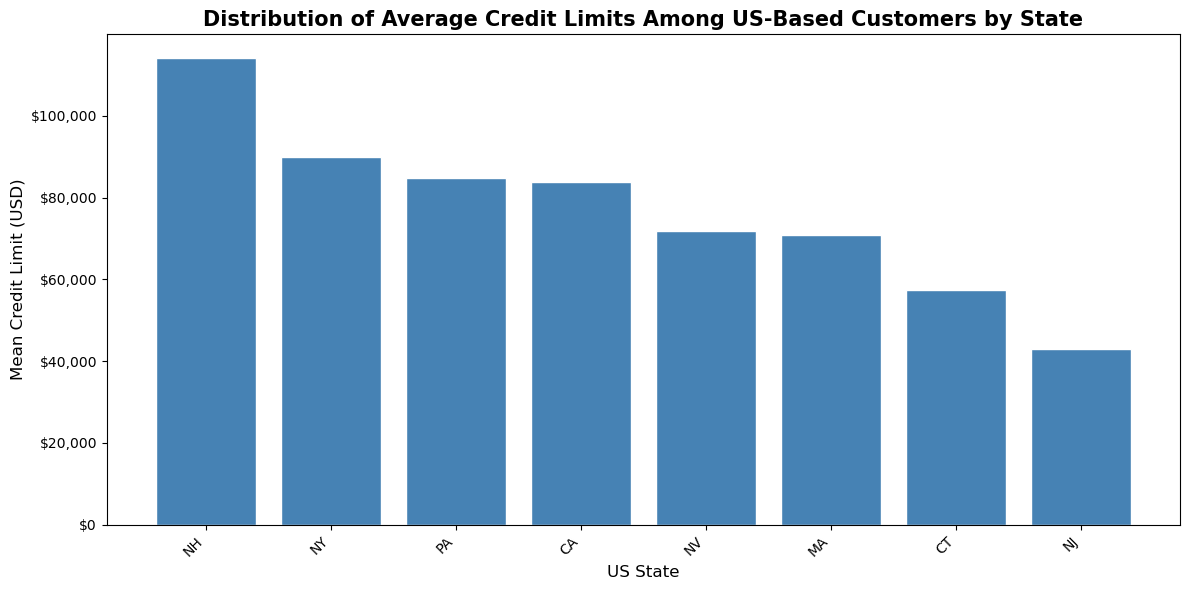

In [5]:

#figure size 
fig, ax = plt.subplots(figsize=(12, 6))

#plotting averaage credit limit per state 
ax.bar(df_credit['state'], df_credit['avgCredit'], color='steelblue', edgecolor='white')

#Verbose title 
ax.set_title('Distribution of Average Credit Limits Among US-Based Customers by State', 
             fontsize=15, fontweight='bold')
#label the axis 
ax.set_xlabel('US State', fontsize=12)
ax.set_ylabel('Mean Credit Limit (USD)', fontsize=12)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:,.0f}'))

plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### Step 5: Top Customers - Visual Required
The company is approaching its 10 year anniversary and wants to acknowledge and thank its top customers with personalized communication. They have asked you to determine the top 10 customers based on the total amount of payments made, making sure to return the customer name for clarity. 

Execute a SQl query that returns the information required to address this ask.


In [6]:
# Replace None with your code

query5 = """
SELECT c.customerName, SUM(p.amount) AS totalPayments
FROM customers c 
JOIN payments p ON c.customerNumber = p.customerNumber 
GROUP BY c.customerName
ORDER BY totalPayments DESC 
LIMIT 10

"""

df_top_10_customers = pd.read_sql_query(query5, conn_db)
df_top_10_customers

,customerName,totalPayments
0,Euro+ Shopping Channel,715738.98
1,Mini Gifts Distributors Ltd.,584188.24
2,"Australian Collectors, Co.",180585.07
3,Muscle Machine Inc,177913.95
4,"Dragon Souveniers, Ltd.",156251.03
5,"Down Under Souveniers, Inc",154622.08
6,"AV Stores, Co.",148410.09
7,"Anna's Decorations, Ltd",137034.22
8,Corporate Gift Ideas Co.,132340.78
9,"Saveley & Henriot, Co.",130305.35


Once you have the information returned in a dataframe, select an appropriate visualization to represent this data. You are welcome to utilize matplotlib, seaborn, or pandas plotting to produce your visual. Ensure that it has a verbose title and axis labels!

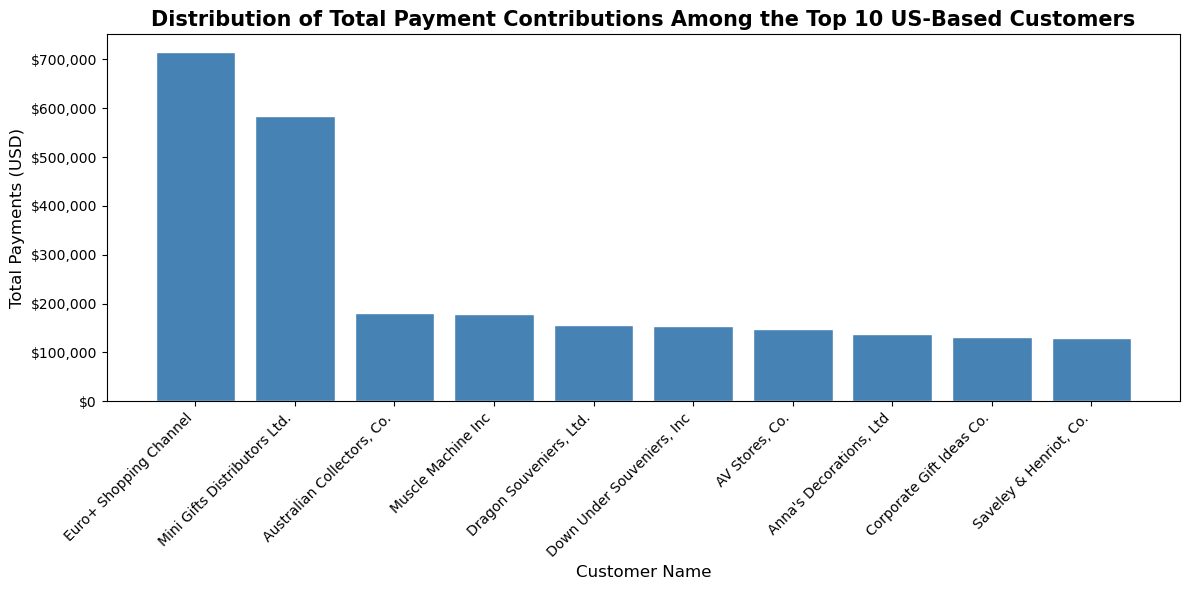

In [7]:
# Replace None with your visual code
# Produce a visual to represent the top ten customers in terms of total payments

#figure size
fig, ax = plt.subplots(figsize=(12, 6))

# Plotting total payments per customer, ordered highest to lowest
ax.bar(df_top_10_customers['customerName'], df_top_10_customers['totalPayments'], 
       color='steelblue', edgecolor='white')

# Verbose title
ax.set_title('Distribution of Total Payment Contributions Among the Top 10 US-Based Customers', 
             fontsize=15, fontweight='bold')

# Axis labels
ax.set_xlabel('Customer Name', fontsize=12)
ax.set_ylabel('Total Payments (USD)', fontsize=12)

# Formatting y-axis 
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:,.0f}'))

plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


### Step 6: Top Customer + Product Quantities
The product team is running an analysis on popular and common products sold to each customer in order to try and determine what new products they should be looking at to include in their catalog. This data will also be used by individual sales reps to recommend similar products to each customer next time they place an order. 

They have asked you to query information, for each customer, about any product they have purchased 10 or more units of. In addition they would like the full set of data to be sorted in ascending order by the total amount purchased.

Execute a SQl query that returns the information required to address this ask.

Hint: For this one, you'll need to make use of HAVING, GROUP BY, and ORDER BY — make sure you get the order of them correct!

In [8]:
# Replace None with you code

query6 = """
SELECT
 c.customerName, 
 p.productName, 
 SUM(od.quantityOrdered) AS totalQuantity
FROM customers c 
JOIN orders o ON c.customerNumber = o.customerNumber
JOIN orderdetails od ON o.orderNumber = od.orderNumber
JOIN products p ON od.productCode = p.productCode
GROUP BY c.customerName, p.productName
HAVING totalQuantity >=10
ORDER BY totalQuantity DESC 
LIMIT 10

"""

df_totalQuantity = pd.read_sql_query(query6, conn_db)
df_totalQuantity

,customerName,productName,totalQuantity
0,Euro+ Shopping Channel,1992 Ferrari 360 Spider red,308
1,Euro+ Shopping Channel,1958 Chevy Corvette Limited Edition,245
2,Euro+ Shopping Channel,1970 Dodge Coronet,197
3,Euro+ Shopping Channel,1957 Chevy Pickup,183
4,Euro+ Shopping Channel,2002 Chevy Corvette,174
5,Mini Gifts Distributors Ltd.,1939 Cadillac Limousine,167
6,Euro+ Shopping Channel,1956 Porsche 356A Coupe,161
7,Euro+ Shopping Channel,1992 Porsche Cayenne Turbo Silver,161
8,Euro+ Shopping Channel,1949 Jaguar XK 120,158
9,Euro+ Shopping Channel,1954 Greyhound Scenicruiser,157


### Step 7: Product Analysis - Visual Required

The product team is looking into the demand across its different product lines. They are conducting a comprehensive review of its product portfolio and inventory management strategies. You have been asked to query data pertaining to each different product line, that contains the total quantity ordered and the total number of products for each respective product line. By examining the number of products and total quantity ordered for each product line, the company aims to:
1. Optimize product mix:
    - Identify which product lines have the most diverse offerings (high number of products)
    - Determine which lines are most popular (high total quantity ordered)
    - Compare if lines with more products necessarily lead to more orders
2. Improve inventory management:
    - Adjust stock levels based on the popularity of each product line
    - Identify potential overstocking in lines with low order quantities
    - Ensure adequate variety in high-performing product lines
3. Adjust marketing strategy:
    - Focus promotional efforts on product lines with high potential (many products but lower order quantities)
    - Capitalize on the popularity of high-performing lines in marketing campaigns
4. Advise Product development:
    - Invest in expanding product ranges for lines with high order quantities
    - Consider phasing out or revamping product lines with low numbers of products and low order quantities

Hint: Think about how you can and might have to utilize SQL DISTINCT statement

Execute a SQl query that returns the information required to address this ask.

In [9]:
# Replace None with your code

query7 = """
SELECT 
  p.productLine, 
  COUNT(DISTINCT p.productCode) AS numberofProducts,
  SUM(od.quantityOrdered) AS totalQuantity
FROM products p 
JOIN orderdetails od ON p.productCode = od.productCode 
GROUP BY p.productLine
ORDER BY totalQuantity DESC;
"""

df_numberofProducts = pd.read_sql(query7, conn_db)
df_numberofProducts

,productLine,numberofProducts,totalQuantity
0,Classic Cars,37,35582
1,Vintage Cars,24,22933
2,Motorcycles,13,12778
3,Planes,12,11872
4,Trucks and Buses,11,11001
5,Ships,9,8532
6,Trains,3,2818


Once you have the information returned in a dataframe, select an appropriate visualization to represent the relationship between total quantity ordered and the number of products in order to perform a preliminary investigation into the question of if more products lead to more orders. You are welcome to utilize matplotlib, seaborn, or pandas plotting to produce your visual. Ensure that it has a verbose title and axis labels!

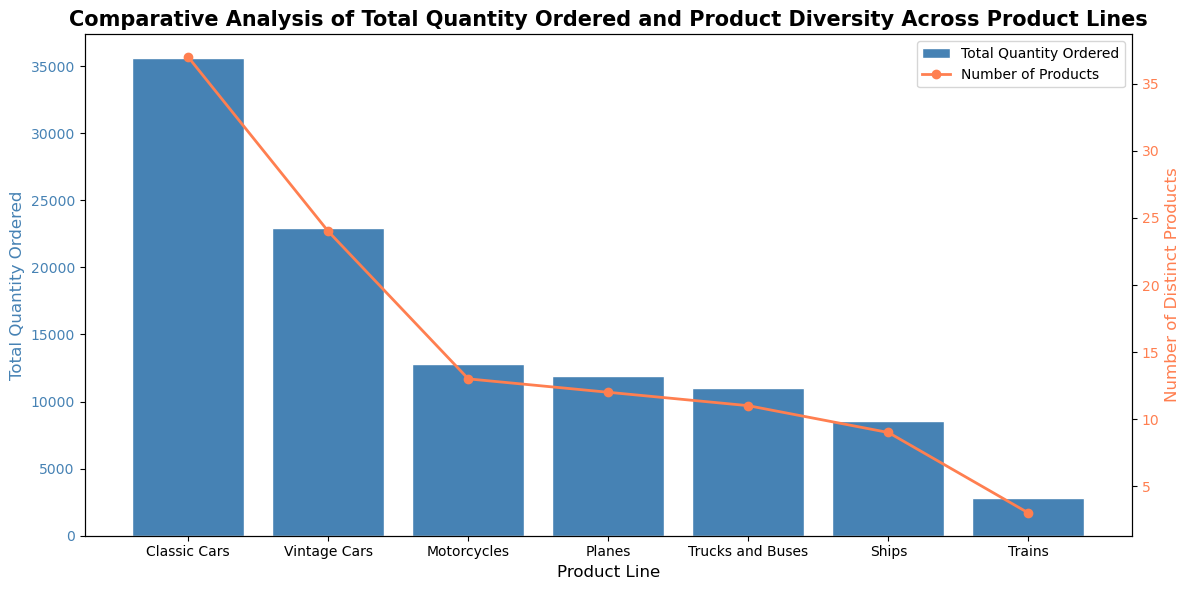

In [10]:
# Replace None with your visual code
# Produce a visual to represent the the relation between number of products and the total amount ordered
# Dual axis chart to compare two metrics on different scales across product lines
fig, ax1 = plt.subplots(figsize=(12, 6))

# Primary axis - total quantity ordered as bars
ax1.bar(df_numberofProducts['productLine'], df_numberofProducts['totalQuantity'],
        color='steelblue', edgecolor='white', label='Total Quantity Ordered')
ax1.set_xlabel('Product Line', fontsize=12)
ax1.set_ylabel('Total Quantity Ordered', fontsize=12, color='steelblue')
ax1.tick_params(axis='y', labelcolor='steelblue')

# Secondary axis - number of products as a line overlay
ax2 = ax1.twinx()
ax2.plot(df_numberofProducts['productLine'], df_numberofProducts['numberofProducts'],
         color='coral', marker='o', linewidth=2, label='Number of Products')
ax2.set_ylabel('Number of Distinct Products', fontsize=12, color='coral')
ax2.tick_params(axis='y', labelcolor='coral')

# Verbose title
ax1.set_title('Comparative Analysis of Total Quantity Ordered and Product Diversity Across Product Lines',
              fontsize=15, fontweight='bold')

# Combined legend for both axes
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper right')

plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## Reflection Question:

Please explain your choice in the type of visual you used in order to highlight and represent the data from the above query. In a non-technical manner explain why that chart type makes sense for the information being conveyed. What does this visual convey in the context of the question it was asked for?

## Type your answer in markdown here!

A dual-axis chart was used as the data presents two metrics with different scales, making a single axis ineffective.
Why this chart type:

Bars represent total quantity ordered — the primary demand metric
An overlaid line tracks number of distinct products — a secondary diversity metric
The dual-axis ensures neither metric visually dominates the other

What the visual conveys:

Whether product lines with more products actually generate higher order volumes
Which product lines are high demand despite limited product variety
Identifies where inventory, marketing and product development efforts should be prioritized 

### Step 8: Remote Offices
Upper management is considering a shift to hybrid and remote work for certain locations and roles. They have tasked you with providing them data about employees who work in any office that has fewer than 5 total employees so they can better understand how to support those employees remotely when offices are shut down. 

Be sure to include information about the employees job and supervisor so management can adjust everyone to remote work properly.

Hint: Utilize a subquery to find the relevant offices

Execute a SQl query that returns the information required to address this ask.

In [11]:
# Replace None with your code

query8 = """ 
SELECT 
   e.employeeNumber,
   e.firstName,
   e.lastName,
   e.jobTitle,
   e.reportsTo AS supervisorNumber,
   mgr.firstName AS supervisorFirstName, 
   mgr.lastName AS supervisorLastName,
   e.officeCode,
   o.city AS officeCity,
   o.country AS officeCountry
FROM employees e 
JOIN offices o ON e.officeCode = o.officeCode
JOIN employees mgr ON e.reportsTo = mgr.employeeNumber
WHERE e.officeCode IN(
    SELECT officeCode
    FROM employees
    GROUP BY officeCode
    HAVING COUNT(employeeNumber) < 5);
"""

df_remote_employee = pd.read_sql(query8,conn_db)
df_remote_employee

,employeeNumber,firstName,lastName,jobTitle,supervisorNumber,supervisorFirstName,supervisorLastName,officeCode,officeCity,officeCountry
0,1088,William,Patterson,Sales Manager (APAC),1056,Mary,Patterson,6,Sydney,Australia
1,1188,Julie,Firrelli,Sales Rep,1143,Anthony,Bow,2,Boston,USA
2,1216,Steve,Patterson,Sales Rep,1143,Anthony,Bow,2,Boston,USA
3,1286,Foon Yue,Tseng,Sales Rep,1143,Anthony,Bow,3,NYC,USA
4,1323,George,Vanauf,Sales Rep,1143,Anthony,Bow,3,NYC,USA
5,1501,Larry,Bott,Sales Rep,1102,Gerard,Bondur,7,London,UK
6,1504,Barry,Jones,Sales Rep,1102,Gerard,Bondur,7,London,UK
7,1611,Andy,Fixter,Sales Rep,1088,William,Patterson,6,Sydney,Australia
8,1612,Peter,Marsh,Sales Rep,1088,William,Patterson,6,Sydney,Australia
9,1619,Tom,King,Sales Rep,1088,William,Patterson,6,Sydney,Australia


## Reflection Question:

Describe how you decided on the subquery that you used in the query above? This answer can be technically in nature, describing your thought process in how the main query is utilizing the subquery to return the correct data.

## Type your answer in markdown here!



-The subquery was structured to first isolate offices meeting the headcount threshold before filtering the main employee dataset. 
-Using officeCode as the grouping key, the subquery brings togther all employees by office, tallies the headcount, and returns only those offices with fewer than five employees. 
-HAVING was applied rather than WHERE as the filtering occurs after aggregating the values. 
-The outer query then joins the employees and offices tables to retrieve location details, applies a LEFT JOIN to capture supervisor information, and scopes the final results to qualifying offices via WHERE e.officeCode IN (subquery). This two-step structure improves both readability and maintainability, avoiding the complexity of consolidating all logic into a single query.

### Step 9: Close the Connection

Now that you are finished executing your queries and retrieving the required information you always want to make sure to close the connection to your database.

In [12]:
# Replace None with your code

conn_db.close()

### End of Guided Section
In this initial portion of the assessment, you produced several data queries and visualizations for a model company, mainly focused around its customer and product data. You wrote and engineered specific SQL queries to address pertinent questions and asks from the company. Along the way, you utilized many of the major concepts and keywords associated with SQL SELECT queries: FROM, WHERE, GROUP BY, HAVING, ORDER BY, JOIN, SUM, COUNT, and AVG.

## Part 2: Exploratory Analysis with SQL
In this open-ended exploratory section, you will analyze real-world data from the movie industry. As a data analyst, you have the freedom to investigate questions and topics that intrigue you within this dataset. The database schema and Entity-Relationship Diagram (ERD) are provided below for your reference. A general overview and instructions are also provided below.

In [13]:
# Run this cell without changes
import zipfile

zip_file_path = 'im.db.zip'
extract_to_path = './'

with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
    zip_ref.extractall(extract_to_path)

# Connection
conn4 = sqlite3.connect('im.db')

# Schema
schema_df = pd.read_sql("""
SElECT * FROM sqlite_master                        
""", conn4)
schema_df

,type,name,tbl_name,rootpage,sql
0,table,movie_basics,movie_basics,2,"CREATE TABLE ""movie_basics"" (\n""movie_id"" TEXT..."
1,table,directors,directors,3,"CREATE TABLE ""directors"" (\n""movie_id"" TEXT,\n..."
2,table,known_for,known_for,4,"CREATE TABLE ""known_for"" (\n""person_id"" TEXT,\..."
3,table,movie_akas,movie_akas,5,"CREATE TABLE ""movie_akas"" (\n""movie_id"" TEXT,\..."
4,table,movie_ratings,movie_ratings,6,"CREATE TABLE ""movie_ratings"" (\n""movie_id"" TEX..."
5,table,persons,persons,7,"CREATE TABLE ""persons"" (\n""person_id"" TEXT,\n ..."
6,table,principals,principals,8,"CREATE TABLE ""principals"" (\n""movie_id"" TEXT,\..."
7,table,writers,writers,9,"CREATE TABLE ""writers"" (\n""movie_id"" TEXT,\n ..."


## The Data

![movie ERD](images/movie_data_erd.jpeg)
### Database Content:

- Source: IMDB
- Time Range: Movies released between 2010 and 2019
- Note: Exclude any movies with a start_year after 2019 as this data is not current or accurate

Available Data Categories:
- Genre
- Runtime
- Personnel (writers, directors, actors)
- Movie ratings

### Objectives:

Initial Exploration:
- Use SQL in combination with Pandas to explore the database
- Identify interesting trends, patterns, or relationships in the data

Business Question Formulation:
- Develop at least one substantial business question for deeper analysis
- Ensure the question is relevant, specific, and can be addressed with the available data

Data Cleaning Assessment:
- Identify potential data cleaning tasks necessary for your deeper analysis
- Note: You are not required to perform the cleaning, only to recognize and list the necessary tasks

Null Value Handling:
- Be aware that the dataset contains null values in certain fields
- Exclude these null values from your exploration
- Do not attempt to input or fill in missing information

### Deliverables:

You need to produce a short slide presentation (3-5 slides) that highlights the three key deliverables below. Utilize a data visualization to support the second deliverable.

1. A summary of your initial data exploration findings
    - Can be bulleted or sentence form
2. At least one well-formulated business question for further analysis
    - Should stem from a relevant trend or pattern your initial exploration identified
3. A list of potential data cleaning tasks identified during your exploration
    - This can and should include things like data normalization/standardization and null handling

Tips for Success:

Begin with broad exploratory queries to understand the data's scope and content. Then focus on honing in on interesting relationships between different data categories. Consider industry trends, audience preferences, or financial aspects when formulating your business question. Pay attention to data quality issues, inconsistencies, or limitations that might affect your analysis. Remember, the goal is to demonstrate your analytical thinking and ability to derive meaningful insights from complex datasets. Good luck with your exploration!

NOTE: You do not need to explore every aspect of this database. Find something that you think is interesting or relevant about the data and focus your exploration there.

In [18]:
# Begin your code here

# connect to the database 

conn = sqlite3.connect('im.db')


#check tables in the database 

tables_im = pd.read_sql(
    ''' SELECT name FROM sqlite_master WHERE type = "table"
    ''', conn
)

print(tables_im)

            name
0   movie_basics
1      directors
2      known_for
3     movie_akas
4  movie_ratings
5        persons
6     principals
7        writers


In [20]:
# Row count per table to understand the scale of the database
for table in tables_im['name'].tolist():
    count = pd.read_sql(f'SELECT COUNT(*) AS row_count FROM {table}', conn)
    print(f'{table}: {count["row_count"][0]:,} rows')

movie_basics: 146,144 rows
directors: 291,174 rows
known_for: 1,638,260 rows
movie_akas: 331,703 rows
movie_ratings: 73,856 rows
persons: 606,648 rows
principals: 1,028,186 rows
writers: 255,873 rows


In [28]:
#check the total movie count per year 

q1 = """
SELECT start_year, COUNT(*) AS total_movie_count
FROM movie_basics mb
WHERE start_year BETWEEN 2010 AND 2018
GROUP BY start_year
ORDER BY start_year
"""

df_total_movie_count = pd.read_sql(q1, conn)
df_total_movie_count

,start_year,total_movie_count
0,2010,11849
1,2011,12900
2,2012,13787
3,2013,14709
4,2014,15589
5,2015,16243
6,2016,17272
7,2017,17504
8,2018,16849


In [27]:
#Genre distribution 

q2 = """  
SELECT genres,COUNT(*) AS movie_count
FROM movie_basics
WHERE start_year BETWEEN 2010 AND 2018
  AND genres IS NOT NULL 
GROUP BY genres 
ORDER BY movie_count DESC
LIMIT 10
"""

df_genre_dist = pd.read_sql(q2, conn)
df_genre_dist

,genres,movie_count
0,Documentary,30324
1,Drama,19857
2,Comedy,8449
3,Horror,3927
4,"Comedy,Drama",3275
5,Thriller,2651
6,"Biography,Documentary",2073
7,Action,1981
8,"Drama,Romance",1972
9,"Documentary,Drama",1528


## Business Question

Which movie genres experienced the most significant growth or decline in production volume between 2010 and 2018, and what does this indicate about trendsin  market demand and audience preferences?

This question stems from the observable variation in genre production counts across 
the decade. By identifying which genres are growing or declining in output, studios 
and streaming platforms can make more informed decisions about where to direct 
production investment and budegt appropriately.

In [33]:
#Data cleaning 
#Find the total number of missing values in the genres section. Also find which movies fall in single vs multiple genres 

q3 = """ 
SELECT 
    COUNT (*) AS total_movies,
    SUM (CASE WHEN genres is NULL THEN 1 ELSE 0 END) AS missing_genres,
    COUNT(DISTINCT genres) AS unique_gen_combination,
    SUM(CASE WHEN genres LIKE "%,%" THEN 1 ELSE 0 END) as multi_genre_movie,
    SUM(CASE WHEN genres NOT LIKE '%,%' THEN 1 ELSE 0 END) AS single_genre_movies
FROM movie_basics
WHERE start_year BETWEEN 2010 AND 2018
"""

df_missing_data = pd.read_sql(q3, conn)
df_missing_data

,total_movies,missing_genres,unique_gen_combination,multi_genre_movie,single_genre_movies
0,136702,5038,1067,56456,75208


In [ ]:
# DATA ANALYSIS
# Count how many movies were produced per genre per year.
# This allows us to track production volume trends over time at a genre level.

q4 = """
SELECT 
    start_year,
    TRIM(SUBSTR(genres, 1, INSTR(genres || ',', ',') - 1)) AS primary_genre,
    COUNT(*) AS movie_count
FROM movie_basics
WHERE start_year BETWEEN 2010 AND 2018
    AND genres IS NOT NULL
GROUP BY start_year, primary_genre
ORDER BY start_year, movie_count DESC
"""

df_genre_trends = pd.read_sql(q4, conn)
df_genre_trends.head(100)

,start_year,primary_genre,movie_count
0,2010,Documentary,3427
1,2010,Drama,2608
2,2010,Comedy,1832
3,2010,Action,891
4,2010,Biography,740
...,...,...,...
95,2014,Documentary,4272
96,2014,Drama,3131
97,2014,Comedy,2384
98,2014,Biography,1263


In [40]:
# To keep the visualization focused and readable, we isolate the top 6 genres
# by total production volume across the entire 2010 to 2018 period.
# We then pivot the dataframe so that each genre becomes its own column
# and each row represents a year — this structure is required for the line chart.

top_genres = df_genre_trends.groupby('primary_genre')['movie_count'].sum().nlargest(6).index.tolist()
print("Top 6 genres by total production volume:", top_genres)

df_top = df_genre_trends[df_genre_trends['primary_genre'].isin(top_genres)]
df_pivot = df_top.pivot(index='start_year', columns='primary_genre', values='movie_count')
df_pivot

Top 6 genres by total production volume: ['Documentary', 'Drama', 'Comedy', 'Action', 'Biography', 'Horror']


primary_genre,Action,Biography,Comedy,Documentary,Drama,Horror
start_year,,,,,,
2010,891,740,1832,3427,2608,465
2011,912,815,1982,3677,2798,532
2012,919,933,2107,3931,2939,601
2013,1008,1155,2252,4013,3063,611
2014,1073,1263,2384,4272,3131,705
2015,1092,873,2314,4913,3388,680
2016,1207,743,2441,5210,3573,740
2017,1257,681,2362,5397,3762,860
2018,1128,548,2442,4740,3959,848


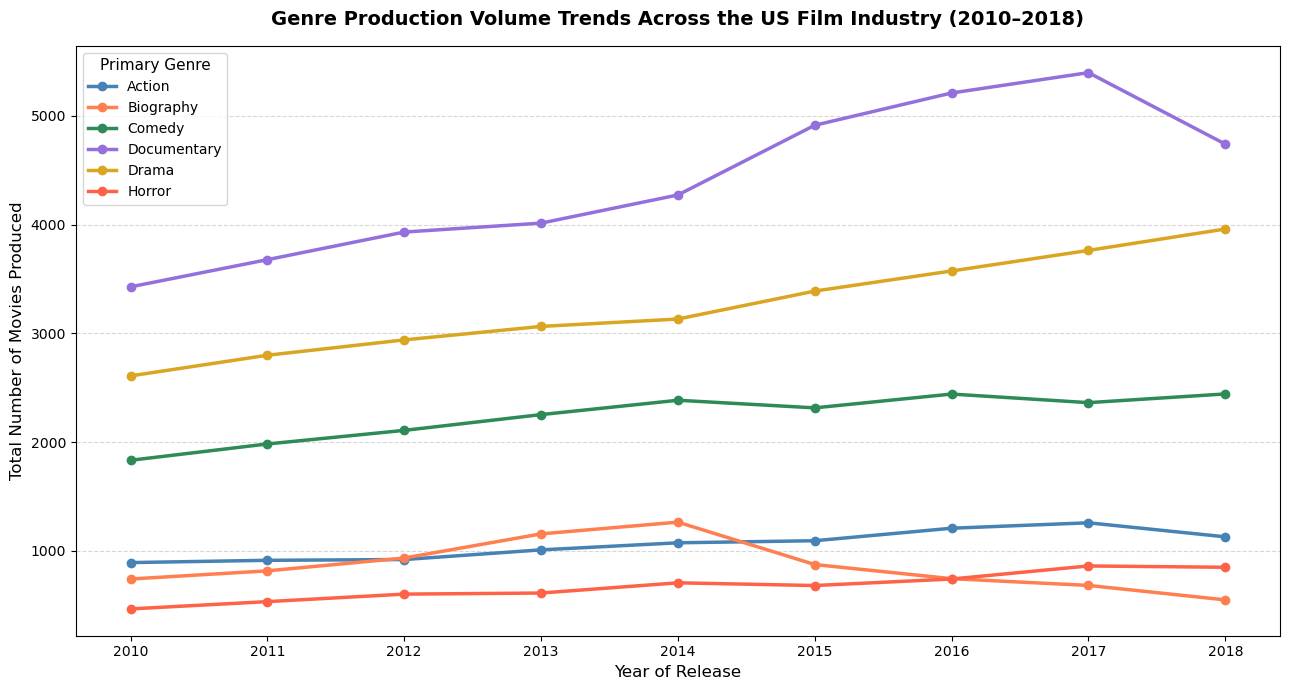

In [ ]:
# I selected a multi-line chart as it is the most appropriate visualization for this analysis.
# Since we are tracking how production volume changes over time across multiple genres,
# a line chart allows for direct comparison of trends simultaneously.
# Each genre is assigned a distinct color and plotted with markers for year-level readability. 


colors = ['steelblue', 'coral', 'seagreen', 'mediumpurple', 'goldenrod', 'tomato']

fig, ax = plt.subplots(figsize=(13, 7))

for i, genre in enumerate(df_pivot.columns):
    ax.plot(df_pivot.index, df_pivot[genre], marker='o', linewidth=2.5,
            label=genre, color=colors[i])

ax.set_title('Genre Production Volume Trends Across the US Film Industry (2010–2018)',
             fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Year of Release', fontsize=12)
ax.set_ylabel('Total Number of Movies Produced', fontsize=12)
ax.legend(title='Primary Genre', fontsize=10, title_fontsize=11)
ax.set_xticks(df_pivot.index)
ax.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

conn.close()